## Imports

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from collections import Counter

In [66]:
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

In [67]:
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [68]:
import torchmetrics

## Loading Image Data

### cuda Check

In [69]:
print("PyTorch version:", torch.__version__)
cudaAvailable = torch.cuda.is_available()
print("CUDA available:", cudaAvailable)
if cudaAvailable:
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version (PyTorch):", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version (PyTorch): 12.6
cuDNN version: 91002


### Configs

#### Device

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
device

device(type='cuda')

#### Data

In [72]:
data_dir = "dataset/"
img_size = 128
batch_size = 64
train_split = 0.8

#### Training Parameters

In [73]:
epochs = 30
learning_rate = 0.001
weight_decay = 1e-4
scheduler_type = "cosine"
label_smoothing = 0.05
dropout = 0.3

#### Saving the Model

In [91]:
seed = 42
CNN_save_path = "CNN.pth"

### Transform

In [75]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [76]:
# train_transform = transforms.Compose([
#     transforms.Resize((img_size, img_size)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
# ])

### Load Data

In [77]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

### Train and Test Split

In [78]:
train_size = int(train_split * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [79]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [80]:
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Classes: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']
Train: 2016 | Test: 505


## Distribution of Images

### Class-Wise Distribution

In [81]:
class_counts = Counter(dataset.targets)
classes = dataset.classes

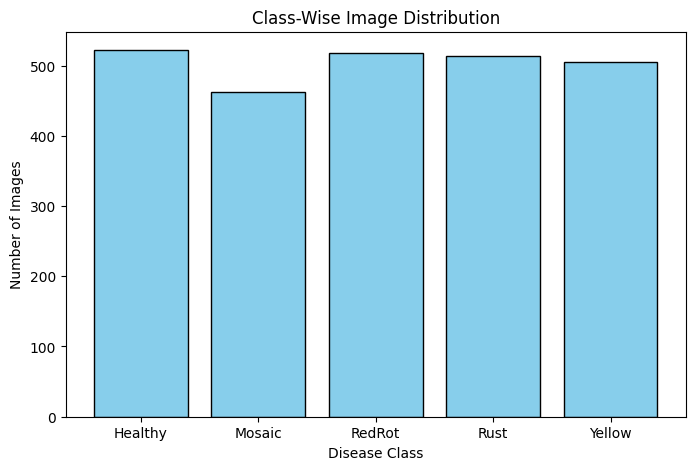

In [82]:
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(8,5))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class-Wise Image Distribution")
plt.show()

### Class-Wise Train-Test Distribution

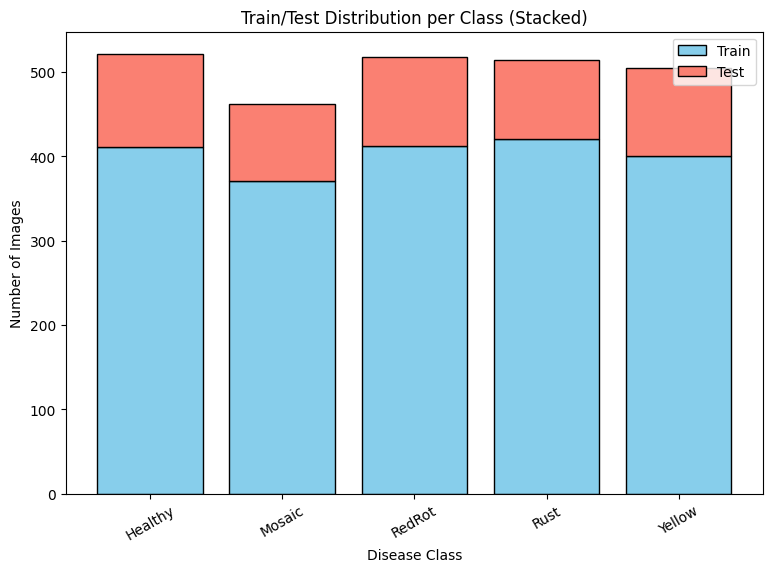

In [83]:
train_counts = Counter([dataset.targets[i] for i in train_dataset.indices])
test_counts  = Counter([dataset.targets[i] for i in test_dataset.indices])

train_vals = [train_counts[i] for i in range(len(classes))]
test_vals  = [test_counts[i] for i in range(len(classes))]

x = range(len(classes))
plt.figure(figsize=(9,6))
plt.bar(x, train_vals, label="Train", color="skyblue", edgecolor="black")
plt.bar(x, test_vals, bottom=train_vals, label="Test", color="salmon", edgecolor="black")

plt.xticks(x, classes, rotation=30)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Train/Test Distribution per Class (Stacked)")
plt.legend()
plt.show()

### Image Distribution Summary

In [84]:
for image_class, count in class_counts.items():
    print(f"{dataset.classes[image_class]}: {count}")

print(f"\nTotal images: {len(dataset)}")

Healthy: 522
Mosaic: 462
RedRot: 518
Rust: 514
Yellow: 505

Total images: 2521


## Model Training

### CNN Model

In [85]:
def conv_block(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

class SugarNet(nn.Module):
    def __init__(self, num_classes, dropout=dropout):
        super().__init__()
        self.stem = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),
        )
        self.stage4 = nn.Sequential(
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),
        )
        self.stage5 = nn.Sequential(
            conv_block(256, 512),
            conv_block(512, 512),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.head(x)
        return x

### Model Setup

In [ ]:
model = SugarNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [ ]:
if scheduler_type == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
elif scheduler_type == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
else:
    scheduler = None

### Training Function

In [ ]:
def train_one_epoch(loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss/total, total_correct/total

### Testing Function

In [ ]:
def test(loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss/total, total_correct/total

### Training Loop

In [ ]:
best_acc = 0.0
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    test_loss, test_acc = test(test_loader)
    if scheduler is not None:
        scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss {train_loss:.4f}, Accuracy {train_acc:.4f} | "
          f"Test Loss {test_loss:.4f}, Accuracy {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), CNN_save_path)

print("\nTraining Complete\nBest Test Accuracy:", best_acc)

Epoch 01/30 | Train Loss 1.1708, Acc 0.5685 | Test Loss 2.2659, Acc 0.3624
Epoch 02/30 | Train Loss 0.9432, Acc 0.6825 | Test Loss 0.9102, Acc 0.7089
Epoch 03/30 | Train Loss 0.7991, Acc 0.7485 | Test Loss 1.3280, Acc 0.6040
Epoch 04/30 | Train Loss 0.7438, Acc 0.7763 | Test Loss 0.8678, Acc 0.7208
Epoch 05/30 | Train Loss 0.6660, Acc 0.8046 | Test Loss 0.7787, Acc 0.7465
Epoch 06/30 | Train Loss 0.6188, Acc 0.8383 | Test Loss 1.4372, Acc 0.6238
Epoch 07/30 | Train Loss 0.5624, Acc 0.8641 | Test Loss 0.8286, Acc 0.7525
Epoch 08/30 | Train Loss 0.5296, Acc 0.8785 | Test Loss 0.6174, Acc 0.8297
Epoch 09/30 | Train Loss 0.4981, Acc 0.8864 | Test Loss 0.7253, Acc 0.7842
Epoch 10/30 | Train Loss 0.4624, Acc 0.9038 | Test Loss 0.6537, Acc 0.8119
Epoch 11/30 | Train Loss 0.4647, Acc 0.8963 | Test Loss 0.5536, Acc 0.8713
Epoch 12/30 | Train Loss 0.4012, Acc 0.9276 | Test Loss 0.5305, Acc 0.8891
Epoch 13/30 | Train Loss 0.3779, Acc 0.9484 | Test Loss 0.4768, Acc 0.9109
Epoch 14/30 | Train Loss 